In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt

In [2]:
env = gym.make("CarRacing-v3", render_mode="rgb_array", lap_complete_percent=0.95, domain_randomize=False, continuous=False)
env

/Users/jakub.jedra/Documents/Brader/inteligencja-obliczeniowa/gym-env/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


<TimeLimit<OrderEnforcing<PassiveEnvChecker<CarRacing<CarRacing-v3>>>>>

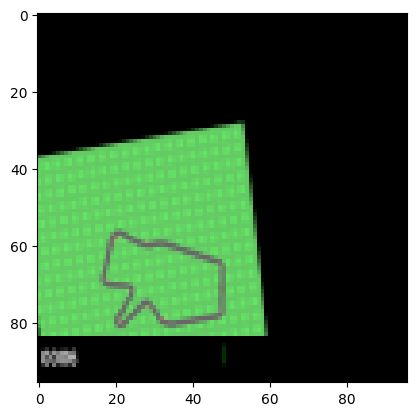

In [3]:
obs, info = env.reset()

plt.imshow(obs)

In [4]:
pos = env.unwrapped.car.hull.position
angle = env.unwrapped.car.hull.angle
print("car position:", float(pos[0]), float(pos[1]), "angle:", float(angle))

car position: 217.72213745117188 -51.26128387451172 angle: -0.13477739691734314


### DQN on Discrete CarRacing: what this does

1. Builds a **discrete-action** CarRacing environment (`continuous=False`).  
2. Wraps it with **Monitor** logging (episode rewards over time).  
3. Trains a **DQN (CnnPolicy)** model on pixel input.  
4. Loads logged rewards and plots the **learning curve** (episode reward vs timesteps).

This is intentionally minimal and easy to modify.

objc[26208]: Class SDLApplication is implemented in both /Users/jakub.jedra/Documents/Brader/inteligencja-obliczeniowa/gym-env/lib/python3.10/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1196512c8) and /Users/jakub.jedra/Documents/Brader/inteligencja-obliczeniowa/gym-env/lib/python3.10/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x131640890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[26208]: Class SDLAppDelegate is implemented in both /Users/jakub.jedra/Documents/Brader/inteligencja-obliczeniowa/gym-env/lib/python3.10/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x119651318) and /Users/jakub.jedra/Documents/Brader/inteligencja-obliczeniowa/gym-env/lib/python3.10/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1316408e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[26208]: Class SDLTranslatorResponder is implemented in 

No checkpoint found. Starting a new training run.
Using mps device
Device: mps
Current steps: 0, target: 300000, remaining: 300000
Logging to ./tb_logs/DQN_2


/Users/jakub.jedra/Documents/Brader/inteligencja-obliczeniowa/gym-env/lib/python3.10/site-packages/rich/live.py:260
: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | -56.3    |
|    exploration_rate | 0.963    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 326      |
|    time_elapsed     | 12       |
|    total_timesteps  | 4000     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | -57.9    |
|    exploration_rate | 0.925    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 239      |
|    time_elapsed     | 33       |
|    total_timesteps  | 8000     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000159 |
|    n_updates        | 749      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean    

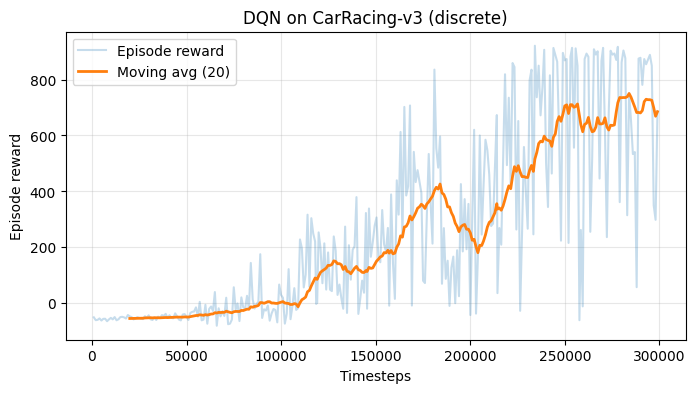

In [5]:
# Minimal DQN training on discrete CarRacing + learning curve
from pathlib import Path
import re

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.vec_env import VecTransposeImage

# In discrete mode, action space is Discrete(5)
# (noop, left, right, gas, brake)
def make_discrete_env():
    return gym.make(
        "CarRacing-v3",
        render_mode="rgb_array",
        continuous=False,
        lap_complete_percent=0.95,
        domain_randomize=False,
    )

log_dir = Path("./logs/dqn_discrete")
log_dir.mkdir(parents=True, exist_ok=True)

checkpoint_dir = Path("./checkpoints/dqn_discrete")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_prefix = "dqn_carracing_step"
checkpoint_every_steps = 25_000

target_total_timesteps = 300_000

def checkpoint_step(path: Path) -> int:
    try:
        return int(path.stem.rsplit("_", 1)[-1])
    except ValueError:
        return -1

venv = make_vec_env(
    make_discrete_env,
    n_envs=1,
    monitor_dir=str(log_dir),
    seed=42,
)
venv = VecTransposeImage(venv)  # HWC -> CHW for CnnPolicy

device = "mps" if torch.backends.mps.is_available() else "cpu"

latest_checkpoint = max(
    checkpoint_dir.glob(f"{checkpoint_prefix}_*.zip"),
    key=checkpoint_step,
    default=None,
)

if latest_checkpoint is not None and checkpoint_step(latest_checkpoint) >= 0:
    print(f"Resuming from checkpoint: {latest_checkpoint}")
    model = DQN.load(str(latest_checkpoint), env=venv, device=device)

    replay_buffer_path = checkpoint_dir / f"{latest_checkpoint.stem}_replay_buffer.pkl"
    if replay_buffer_path.exists():
        model.load_replay_buffer(str(replay_buffer_path))
        print(f"Loaded replay buffer: {replay_buffer_path}")
    else:
        print("Replay buffer file not found for this checkpoint; continuing without it.")
else:
    print("No checkpoint found. Starting a new training run.")
    model = DQN(
        policy="CnnPolicy",
        env=venv,
        learning_rate=1e-4,
        buffer_size=30_000,
        learning_starts=5_000,
        batch_size=64,
        train_freq=4,
        target_update_interval=2_000,
        exploration_fraction=0.35,
        exploration_final_eps=0.02,
        optimize_memory_usage=True,
        replay_buffer_kwargs={"handle_timeout_termination": False},
        verbose=1,
        tensorboard_log="./tb_logs",
        seed=42,
        device=device,
    )

checkpoint_callback = CheckpointCallback(
    save_freq=max(checkpoint_every_steps // venv.num_envs, 1),
    save_path=str(checkpoint_dir),
    name_prefix=checkpoint_prefix,
    save_replay_buffer=True,
    save_vecnormalize=False,
)

current_steps = int(model.num_timesteps)
remaining_timesteps = max(0, target_total_timesteps - current_steps)

print(f"Device: {device}")
print(f"Current steps: {current_steps}, target: {target_total_timesteps}, remaining: {remaining_timesteps}")

if remaining_timesteps > 0:
    model.learn(
        total_timesteps=remaining_timesteps,
        reset_num_timesteps=False,
        progress_bar=True,
        callback=checkpoint_callback,
    )
else:
    print("Target already reached. Increase target_total_timesteps to continue training.")

model.save("dqn_carracing_discrete")
model.save_replay_buffer("dqn_carracing_discrete_replay_buffer.pkl")
venv.close()

# Learning curve from Monitor logs
x, y = ts2xy(load_results(str(log_dir)), "timesteps")

if len(y) == 0:
    print("No episode rewards logged yet. Train for more timesteps.")
else:
    window = 20
    if len(y) >= window:
        y_smooth = np.convolve(y, np.ones(window) / window, mode="valid")
        x_smooth = x[window - 1 :]
    else:
        y_smooth = y
        x_smooth = x

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, alpha=0.25, label="Episode reward")
    plt.plot(x_smooth, y_smooth, linewidth=2, label=f"Moving avg ({window})")
    plt.xlabel("Timesteps")
    plt.ylabel("Episode reward")
    plt.title("DQN on CarRacing-v3 (discrete)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


In [4]:
# Play one episode with the latest trained DQN agent checkpoint
from pathlib import Path
import re

import gymnasium as gym
import torch
from gymnasium.wrappers import RecordVideo
from IPython.display import Video, display
from stable_baselines3 import DQN

MODEL_PATH = "dqn_carracing_discrete"  # fallback: loads dqn_carracing_discrete.zip
CHECKPOINT_PREFIX = "dqn_carracing_step"
CHECKPOINT_DIR_CANDIDATES = [
    Path("./checkpoints/dqn_discrete"),
    Path("./CarRacing/checkpoints/dqn_discrete"),
]
LIVE_WINDOW = False  # True: open a game window, False: save and display mp4 in notebook
MAX_STEPS = 2_000

def checkpoint_step(path: Path) -> int:
    match = re.search(r"_(\d+)_steps$", path.stem)
    return int(match.group(1)) if match else -1

def latest_checkpoint_file(prefix: str) -> Path | None:
    files = []
    for directory in CHECKPOINT_DIR_CANDIDATES:
        if directory.exists():
            files.extend(directory.glob(f"{prefix}_*_steps.zip"))
    return max(files, key=checkpoint_step, default=None)

latest_checkpoint = latest_checkpoint_file(CHECKPOINT_PREFIX)

if latest_checkpoint is not None and checkpoint_step(latest_checkpoint) >= 0:
    model_to_load = str(latest_checkpoint)
else:
    model_to_load = MODEL_PATH

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Loading model: {model_to_load}")
print(f"Inference device: {device}")

if LIVE_WINDOW:
    env_play = gym.make(
        "CarRacing-v3",
        render_mode="human",
        continuous=False,
        lap_complete_percent=0.95,
        domain_randomize=False,
    )
    model_play = DQN.load(model_to_load, device=device)

    obs, info = env_play.reset(seed=123)
    ep_reward = 0.0

    for _ in range(MAX_STEPS):
        action, _ = model_play.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_play.step(action)
        ep_reward += reward
        if terminated or truncated:
            break

    env_play.close()
    print(f"Episode reward (human render): {ep_reward:.1f}")
else:
    video_dir = Path("./videos/agent_play")
    video_dir.mkdir(parents=True, exist_ok=True)

    env_play = gym.make(
        "CarRacing-v3",
        render_mode="rgb_array",
        continuous=False,
        lap_complete_percent=0.95,
        domain_randomize=False,
    )
    env_play = RecordVideo(
        env_play,
        video_folder=str(video_dir),
        episode_trigger=lambda episode_id: True,
        disable_logger=True,
    )
    model_play = DQN.load(model_to_load, device=device)

    obs, info = env_play.reset(seed=123)
    ep_reward = 0.0

    for _ in range(MAX_STEPS):
        action, _ = model_play.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_play.step(action)
        ep_reward += reward
        if terminated or truncated:
            break

    env_play.close()

    latest_video = sorted(video_dir.glob("*.mp4"))[-1]
    print(f"Episode reward (recorded): {ep_reward:.1f}")
    print(f"Saved video: {latest_video}")
    display(Video(str(latest_video), embed=True))

Loading model: checkpoints/dqn_discrete/dqn_carracing_step_300000_steps.zip
Inference device: mps
Episode reward (recorded): 778.9
Saved video: videos/agent_play/rl-video-episode-0.mp4
